In [1]:
import os
import sys

cwd = os.path.dirname(os.getcwd())
mother_dir = os.path.dirname(cwd) + os.sep
# sys.path.append(os.path.abspath(os.path.join(mother_dir , "MAST_tools")))
sys.path.append(mother_dir)
sys.path.append(cwd)
sys.path.append(os.path.join( os.path.dirname(cwd) ) )

import torch
from MAST_transformer import (ComposeTransform, 
                              ForwardFillImputerTransform, 
                            #   SamplewiseNormalizeTransform,
                              FillWithZerosImputerTransform,
                              SamplingtoReferenceTimeTransform)
from utils import read_data_split_csv

# from tsfm_public import (
#     TimeSeriesPreprocessor,
#     TinyTimeMixerForPrediction,
#     TrackingCallback,
#     count_parameters,
#     get_datasets,
# )


/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/

 CECE /home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/


In [13]:
# Determine device to train on
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [14]:
# Create sets of shot IDs for training, validation and testing
train_shots, test_shots, val_shots = read_data_split_csv()

## Common preprocessing at MAST shot level

In [15]:
# Create MAST datasets
ref_freq = 0.005
source_signal_list = [  ( 'magnetics', 'flux_loop_flux' ),
                        ( 'magnetics', 'b_field_pol_probe_ccbv_field' ), 
                        ( 'magnetics', 'b_field_pol_probe_obr_field' ), 
                        ( 'magnetics', 'b_field_pol_probe_obv_field' ),                            
                        ( 'pf_active', 'solenoid_current'),
                        ( 'pf_active', 'coil_voltage'),
                        ( 'pf_active', 'coil_current'),
                        ( 'pulse_schedule', 'i_plasma'),
                        ( 'summary', 'power_nbi'),
                        ( 'equilibrium', 'elongation'), 
                        ( 'equilibrium', 'elongation_axis'),
                        ( 'equilibrium', 'triangularity_upper'), 
                        ( 'equilibrium', 'triangularity_lower'), 
                        ( 'equilibrium', 'minor_radius'), 
                        ( 'equilibrium', 'magnetic_axis_r'), 
                        ( 'equilibrium', 'magnetic_axis_z')  ]
transform_map = {k: ComposeTransform([ForwardFillImputerTransform(),
                                        # SamplewiseNormalizeTransform(),
                                        FillWithZerosImputerTransform(),
                                        SamplingtoReferenceTimeTransform(ref_freq),
                                        # SamplewiseNormalizeTransform()
                                        ]) for k in [ f'{source}-{signal}' for source, signal in source_signal_list ] }

In [16]:
import os
import pandas as pd
import sys

from torch.utils.data import Dataset

cwd = os.path.dirname(os.getcwd())
mother_dir = os.path.dirname(cwd) + os.sep
sys.path.append(os.path.abspath(os.path.join(mother_dir , "MAST_tools")))
sys.path.append(mother_dir)
sys.path.append(cwd)
sys.path.append(os.path.join( os.path.dirname(cwd) ) )

from MAST_tools.signal_utils import MASTSignalManager  
from MAST_tools.store_utils import MASTStorageManager

class MAST_Dataset(Dataset):
    """
    Custom Dataset for loading MAST data
    """

    def __init__(
        self, 
        local:bool,
        shots_list: list[int], 
        source_signal_list = list,
        transform_map=None,
        model_specific_transform=None
        ):

        self.local = local
        self.shots_list = shots_list
        self.source_signal_list = source_signal_list
        self.transform_map = transform_map
        self.model_specific_transform = model_specific_transform


    def __len__(self):
        return len(self.shots_list)


    def __getitem__(self, idx):

        sig = MASTSignalManager()  
        
        store_manager =  MASTStorageManager()

        store = store_manager.make_shot_store(
            shot_info = {
                "shot_id":self.shots_list[idx], 
                "local":self.local # Add among attributes
                }
            )
        
        # loop on groups of x

        shot = {}

        # print(self.source_signal_x_list)
        for source, signal in self.source_signal_list:

            shot_profile = sig.get_profile(
                    data_origin=store,
                    source_name=source,
                    signal_name=signal
                    )
            
            if shot_profile is not None:
                try:
                    shot_time = shot_profile.time.values
                except  AttributeError:
                    shot_time = None
                try:
                    shot_vals = shot_profile.values
                except  AttributeError:
                    shot_vals = None
            else:
                shot_vals = None
                shot_time = None
            
            # fill the tensordict
            # if self.transform_map_x and (x_vals.size >0 and x_time.size >0):
            if self.transform_map and (shot_vals is not None and shot_time is not None):
                #print(source, signal)
                #print('Apply transform because full shot')
                shot[f'{source}-{signal}'] = self.transform_map[f'{source}-{signal}']({"time": shot_time, "values": shot_vals})
            else:
                #print('Empty shot')
                shot[f'{source}-{signal}'] = {"time": shot_time, "values": shot_vals}
            
            # Apply Model-specific transforms to obtain a list of my training objects

        if self.model_specific_transform :
            list_chunks = []
            if all( subval is not None 
                for subdict in shot.values() 
                for subval in subdict.values()) :
                # print('No None in shot')
                list_x, list_y = self.model_specific_transform( shot )
                for xc, yc in zip(list_x, list_y):
                    list_chunks.append( (xc, yc) )
            return list_chunks
        
        else:
            return(shot)


In [17]:
import numpy as np
import os
import sys

import torch


cwd = os.path.dirname(os.getcwd())
mother_dir = os.path.dirname(cwd) + os.sep
sys.path.append(os.path.abspath(os.path.join(mother_dir , "MAST_tools")))
sys.path.append(mother_dir)
sys.path.append(cwd)
sys.path.append(os.path.join( os.path.dirname(cwd) ) )

from collections import defaultdict


class CNNSpecificTransform:
    def __init__(self, parameters_cnn):
        self.param_cnn_x_list = parameters_cnn['x']
        self.param_cnn_y_list = parameters_cnn['y']
        self.dt = parameters_cnn['dt']
    def __call__(self, shot):
        """
        Input:
        torch dict with key 'time' and key 'values'
        Returns: torch dict with key 'time' and key 'values with NaNs forward-filled
        """
        # print('CNN-specific formatting')

        # get min time for all variables of shot
        min_common_time = min(data['values'].shape[-1] for var, data in shot.items())
        # print('min_common_time is ', min_common_time)
        
        # save x data the proper way reduce data to have same time           
        processed_x = {}
        for var, decalage in self.param_cnn_x_list.items():
            # print('shot keys are ', shot.keys())
            # print('var is ', var)
            # print('decalage is ', decalage)
            data = shot[var]
            if decalage=='t':
                processed_x[var] = data['values'][..., :min_common_time-self.dt] 
            elif decalage=='t+dt':
                processed_x[var] = data['values'][..., self.dt:min_common_time] 
            else:
                print('ERROR in decalage')
            # print(f'input shapes for {var}: ', processed_x[var].shape)
        
        # save y data the proper way reduce data to have same time           
        processed_y = {}
        for var, decalage in self.param_cnn_y_list.items():
            # print(var)
            data = shot[var]
            if decalage=='t':
                processed_y[var] = data['values'][..., :min_common_time-self.dt] 
            elif decalage=='t+dt':
                processed_y[var] = data['values'][..., self.dt:min_common_time] 
            else:
                print('ERROR in decalage')
            # print(f'input shapes for {var}: ', processed_y[var].shape)        
        
        # reduce data to have same time 
        array_x = [data.T for var, data in processed_x.items()] 
        array_y = [data.T for var, data in processed_y.items()] 
        # print('input shapes: ', [arr.shape for arr in array_x])
        # print('output shapes: ', [arr.shape for arr in array_y])
        # group arrays by shape for CNN branch
        reshaped_x = self._group_arrays_by_shape(array_x)
        reshaped_x = [arr.squeeze(-1) if arr.shape[-1] == 1 else arr for arr in reshaped_x]
        # print([arr.shape for arr in reshaped_x])
        reshaped_y = self._group_arrays_by_shape(array_y)
        reshaped_y = [arr.squeeze(-1) if arr.shape[-1] == 1 else arr for arr in reshaped_y]
        # print([arr.shape for arr in reshaped_y])
        # get list of windows for x and y
        list_reshaped_x = [ [channel for channel in window] 
                           for window in [ [arr[timestamp] 
                                            for arr in reshaped_x] 
                                            for timestamp in range(min_common_time-self.dt) ] ]
        # print('\nlen(list_reshaped_x)', len(list_reshaped_x))
        list_reshaped_y = [ window[0]
                           for window in [ [arr[timestamp]
                                            for arr in reshaped_y] 
                                            for timestamp in range(min_common_time-self.dt) ] ]
        # print('len(list_reshaped_y)', len(list_reshaped_y))

        return list_reshaped_x, list_reshaped_y

    def _group_arrays_by_shape(self, arrays):
        grouped = defaultdict(list)
        for arr in arrays:
            grouped[arr.shape].append(arr)
        reshaped_list = []
        for same_shape_group in grouped.values():
            stacked = np.stack(
                        [a for a in same_shape_group]
                    )
            transposed = np.transpose(stacked, axes=[1, 0] + list(range(2, stacked.ndim)))
            # print(transposed.shape)
            reshaped_list.append(transposed)
        # print([ arr.shape for arr in reshaped_list ])
        return reshaped_list

In [18]:
import os
import sys

cwd = os.path.dirname(os.getcwd())
mother_dir = os.path.dirname(cwd) + os.sep
# sys.path.append(os.path.abspath(os.path.join(mother_dir , "MAST_tools")))
sys.path.append(mother_dir)
sys.path.append(cwd)
sys.path.append(os.path.join( os.path.dirname(cwd) ) )

import torch
from MAST_transformer import (ComposeTransform, 
                              ForwardFillImputerTransform, 
                              SamplewiseNormalizeTransform,
                              FillWithZerosImputerTransform,
                              SamplingtoReferenceTimeTransform)
from utils import read_data_split_csv, create_MAST_dataset
from CNN_model import MultiBranchCNNModel


In [19]:
from torch.utils.data._utils.collate import default_collate

def flatten_then_collate(batch):
    # Flatten the batch of lists into a single list
    flattened_batch = [item for sublist in batch for item in sublist]
    print(f'Number of samples from batch = {len(batch)} shots is N = {len(flattened_batch)}')
    # Use the default collate function
    return default_collate(flattened_batch)


In [20]:
# ------------------------------------------------------------------------------------ #
# CNN PIPELINE

# Create CNN datasets
parameters_cnn = {  'x': { 'magnetics-flux_loop_flux' : 't',
                        'magnetics-b_field_pol_probe_ccbv_field' : 't',
                        'magnetics-b_field_pol_probe_obr_field' : 't',
                        'magnetics-b_field_pol_probe_obv_field' : 't',
                        'pf_active-solenoid_current' : 't',
                        'pf_active-coil_voltage' : 't',
                        'pf_active-coil_current' : 't',
                        'pulse_schedule-i_plasma' : 't',
                        'summary-power_nbi' : 't',
                        },
                    'y': { 'equilibrium-elongation' : 't+dt',
                        'equilibrium-elongation_axis' : 't+dt',
                        'equilibrium-triangularity_upper' : 't+dt',
                        'equilibrium-triangularity_lower' : 't+dt',
                        'equilibrium-minor_radius' : 't+dt',
                        'equilibrium-magnetic_axis_r' : 't+dt',
                        'equilibrium-magnetic_axis_z' : 't+dt', 
                        },
                    'dt': int(0.025/ref_freq)
                }


In [21]:
from torch.utils.data import DataLoader, Dataset

train_dataset = MAST_Dataset(local = True, 
                             shots_list = train_shots[0:30], 
                             source_signal_list = source_signal_list, 
                             transform_map=transform_map,
                             model_specific_transform=CNNSpecificTransform(parameters_cnn))
print("len(mast_train_dataset)", len(train_dataset))

val_dataset = MAST_Dataset(local = True, 
                             shots_list =val_shots[0:10], 
                             source_signal_list = source_signal_list, 
                             transform_map=transform_map,
                             model_specific_transform=CNNSpecificTransform(parameters_cnn))
print("len(val_dataset)", len(val_dataset))

test_dataset = MAST_Dataset(local = True, 
                             shots_list = test_shots[0:10], 
                             source_signal_list = source_signal_list, 
                             transform_map=transform_map,
                             model_specific_transform=CNNSpecificTransform(parameters_cnn))
print("len(test_dataset)", len(test_dataset))


train_dataloader = DataLoader( train_dataset,
           batch_size=8,
           num_workers=0,
           shuffle=True,
        #    drop_last=True, 
           collate_fn = flatten_then_collate)

val_dataloader = DataLoader( val_dataset,
           batch_size=8,
           num_workers=0,
           shuffle=True,
        #    drop_last=True, 
           collate_fn = flatten_then_collate)

test_dataloader = DataLoader( train_dataset,
           batch_size=8,
           num_workers=0,
           shuffle=True,
        #    drop_last=True, 
           collate_fn = flatten_then_collate)

len(mast_train_dataset) 30
len(val_dataset) 10
len(test_dataset) 10


In [22]:
for batch_idx, (x_train, y_train) in enumerate(train_dataloader):
        print(batch_idx)
        x_train = [arr.to(torch.float32).to(device) for arr in x_train]
        print( [arr.shape for arr in x_train] )
        # print(y_train.min().item(), y_train.max().item())
        y_train = y_train[0].to(torch.float32).to(device)
        print(y_train.shape)

KeyboardInterrupt: 

## Create CNN Dataset ( on all shots )

## Initialization and training of CNN model 

In [28]:
# Create CNN architecture
input_shapes = [arr.shape for arr in train_dataloader.dataset[0][0][0] ]
print('input_shapes', input_shapes)
output_shape = train_dataloader.dataset[0][0][1].shape
print('output_shape', output_shape)
model = MultiBranchCNNModel(input_shapes, output_shape).to(device)

input_shapes [(1, 15), (1, 40), (2, 18), (3,), (2, 14)]
output_shape (7,)


In [35]:
# Train CNN model
num_epochs = 500
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = float('inf')
patience = 5  # You can change this
epochs_no_improve = 0
early_stop = False

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for batch_idx, (x_train, y_train) in enumerate(train_dataloader):
        print(f'Batch size is {len(y_train)}')

        x_train = [arr.to(torch.float32).to(device) for arr in x_train]
        # print([arr.shape for arr in x_train])
        # print(y_train.min().item(), y_train.max().item())
        y_train = y_train.to(torch.float32).to(device)
        # print(y_train.shape)

        outputs = model(*x_train).squeeze()
        # print('outputs', outputs.shape)
        loss = criterion(outputs, y_train)
        # print('loss', loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += len(y_train)
        print( ' num_batch us', num_batches)

    avg_loss = running_loss / num_batches
    # print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    # Validation phase & Early stopping check

    model.eval()
    val_running_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for x_val, y_val in val_dataloader:
            x_val = [arr.to(torch.float32).to(device) for arr in x_val]
            y_val = y_val.to(torch.float32).to(device)

            val_outputs = model(*x_val).squeeze()
            val_loss = criterion(val_outputs, y_val)

            val_running_loss += val_loss.item()
            val_batches += len(y_val)

    avg_val_loss = val_running_loss / val_batches
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # Save best model state
        torch.save(best_model_state, "cnn_model/best_model.pt")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            early_stop = True
            break
    
    break

# Optionally restore best model weights
if early_stop:
    model.load_state_dict(best_model_state)



model.eval()  # Set the model to evaluation mode
test_loss = 0.0
criterion = torch.nn.MSELoss()  # or whatever you used during training

with torch.no_grad():  # Disable gradient calculation for efficiency
    for x_test, y_test in test_dataloader:
        x_test = [arr.to(torch.float32).to(device) for arr in x_test]
        y_test = y_test.to(torch.float32).to(device)

        outputs = model(*x_test).squeeze()
        loss = criterion(outputs, y_test)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_dataloader)
print(f"Test Loss: {avg_test_loss:.4f}")

Number of samples from batch = 8 shots is N = 931
Batch size is 931
 num_batch us 931


KeyboardInterrupt: 

## Visualization for test shots

In [23]:
# Create CNN architecture
input_shapes = [arr.shape for arr in train_dataloader.dataset[0][0][0] ]
print('input_shapes', input_shapes)
output_shape = train_dataloader.dataset[0][0][1].shape
print('output_shape', output_shape)
model = MultiBranchCNNModel(input_shapes, output_shape).to(device)

model.load_state_dict(torch.load("cnn_model/best_model.pt", map_location=torch.device('cpu')))

input_shapes [(1, 15), (1, 40), (2, 18), (3,), (2, 14)]
output_shape (7,)


<All keys matched successfully>

In [24]:
ref_freq

0.005

In [ ]:

from MAST_dataset import MAST_Dataset
from CNN_transform import CNNSpecificTransform

len(mast_test_dataset) 3
dataloader ok
Number of samples from batch = 1 shots is N = 110
Number of samples from batch = 1 shots is N = 113
Number of samples from batch = 1 shots is N = 110
Test Loss: 0.0312


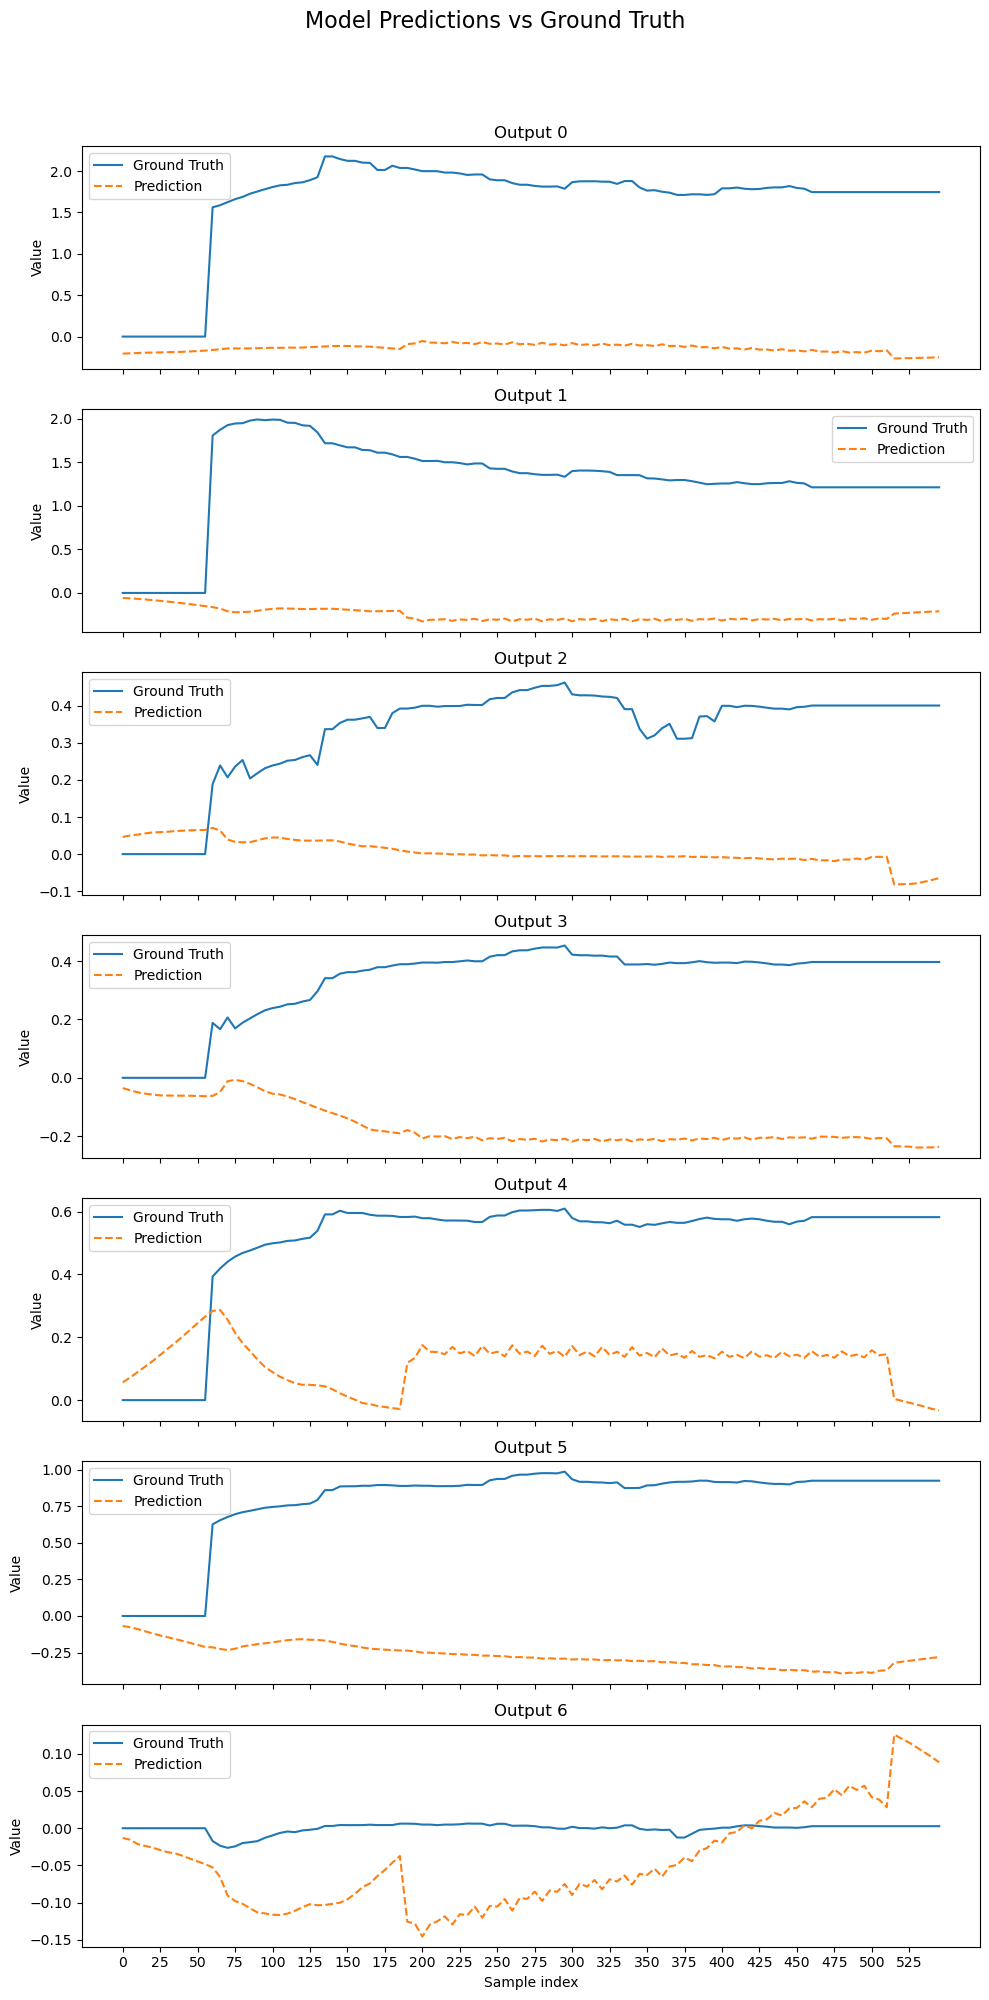

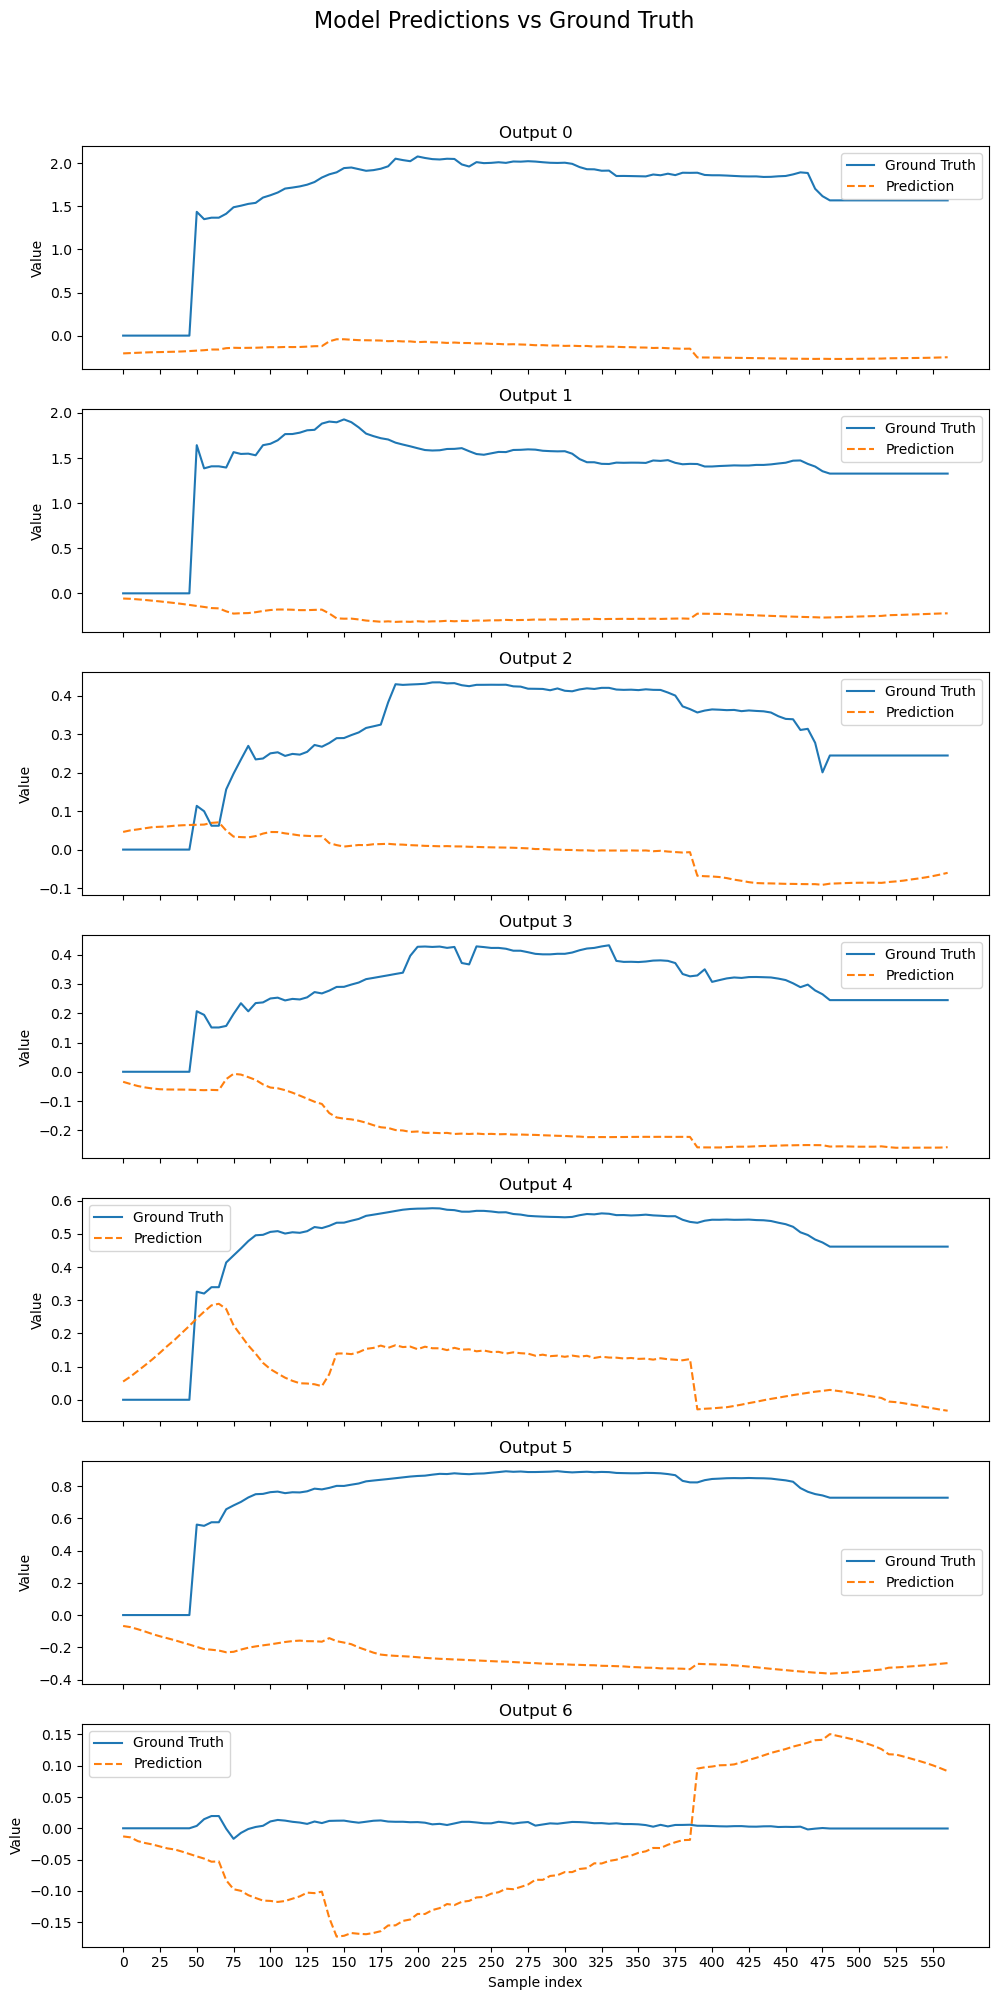

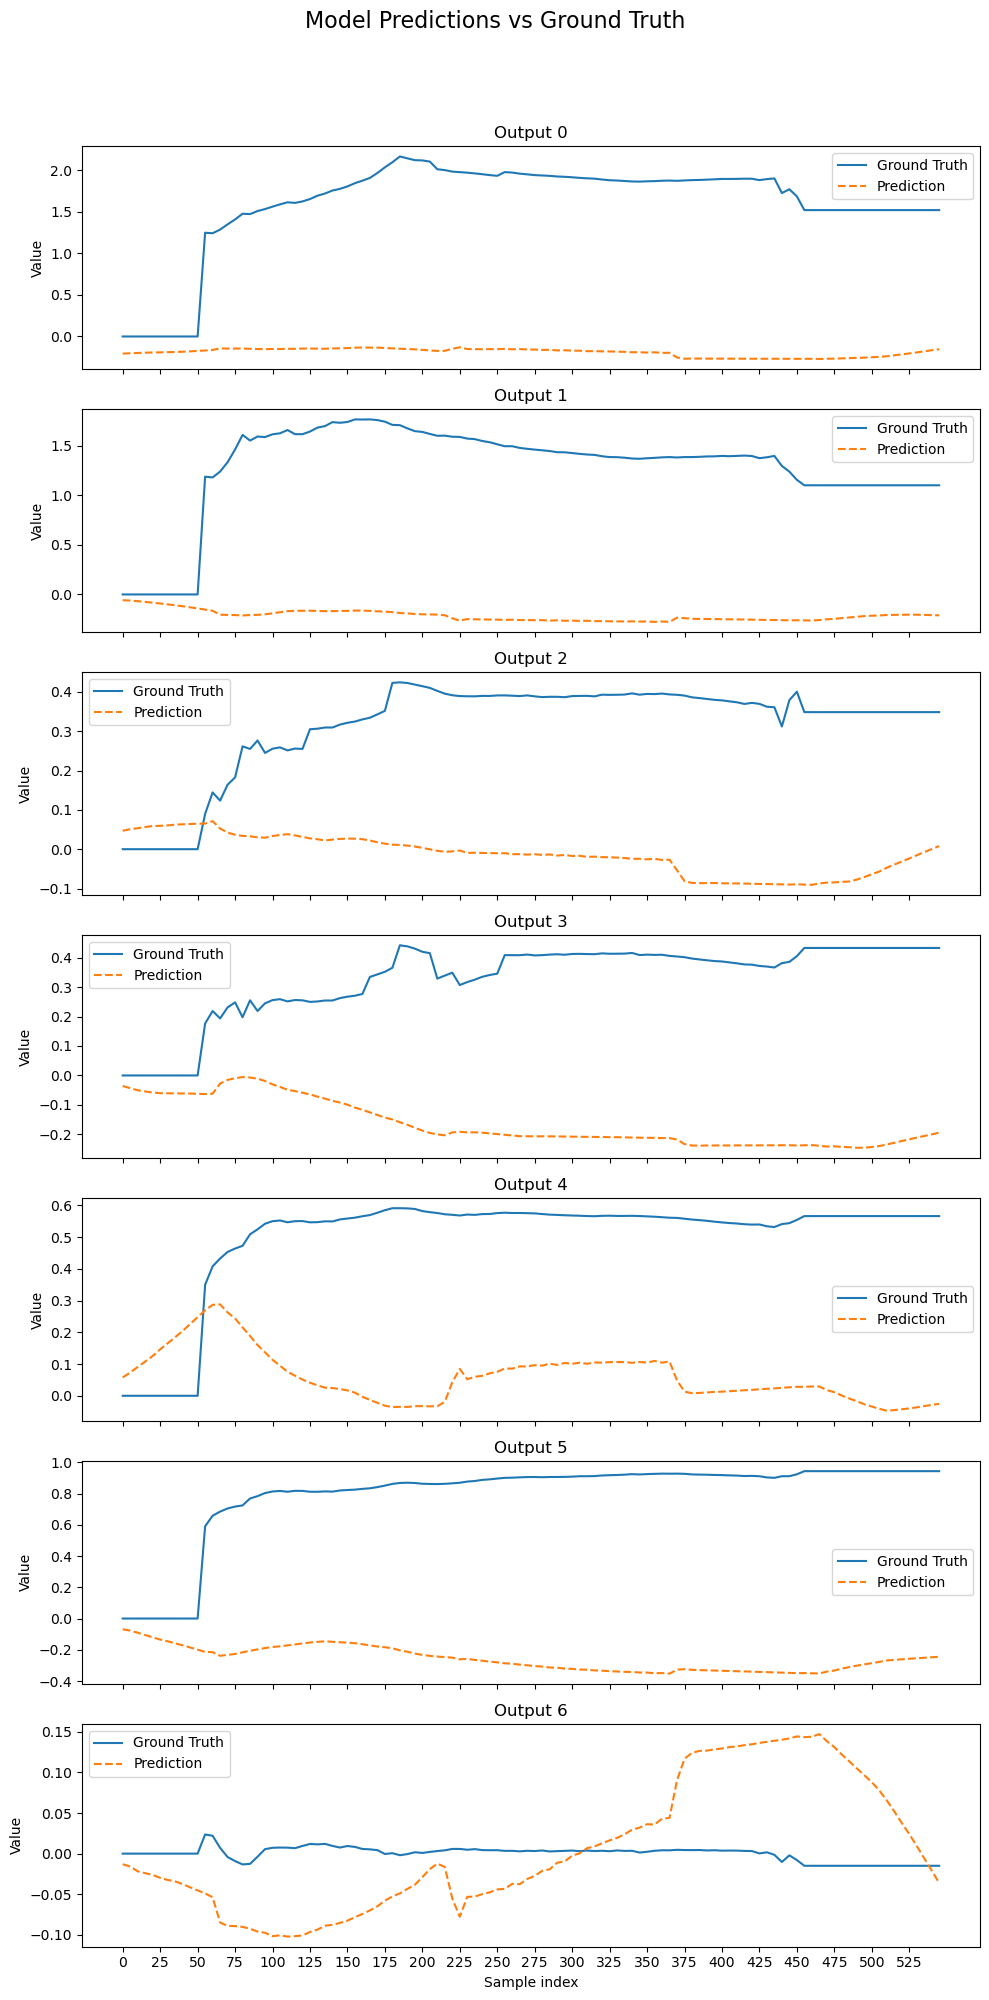

In [50]:
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader
import torch

from MAST_dataset import MAST_Dataset
# from scripts.pipeline_cecile.CNN_transform import CNN_Dataset

## Do Vizualization for just one shot !!!

# for shot_id in test_shots[0:3] :

    # print(shot_id)

cnn_shot_dataset = MAST_Dataset(local = True, 
                            shots_list = test_shots[0:3], 
                            source_signal_list = source_signal_list, 
                            transform_map=transform_map,
                            model_specific_transform=CNNSpecificTransform(parameters_cnn))
print("len(mast_test_dataset)", len(cnn_shot_dataset))

shot_dataloader = DataLoader(
        cnn_shot_dataset,
        batch_size=1,
        num_workers=0,
        shuffle=False,
        collate_fn = flatten_then_collate
    )

print("dataloader ok")

model.eval()  # Set model to eval mode
criterion = torch.nn.MSELoss()
test_loss = 0.0
y_preds = []
y_trues = []

with torch.no_grad():
    for x_test, y_test in shot_dataloader:
        # Convert inputs to tensors with batch dim = 1
        # x_test = [torch.tensor(arr, dtype=torch.float32).to(device) for arr in x_test]
        # y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

        x_test = [arr.to(torch.float32).to(device) for arr in x_test]
        y_test = y_test.to(torch.float32).to(device)
        
        outputs = model(*x_test)
        loss = criterion(outputs, y_test)
        test_loss += loss.item()

        y_preds.append(outputs.cpu().squeeze(0).numpy())  # Remove batch dim before numpy
        y_trues.append(y_test.cpu().squeeze(0).numpy())

avg_test_loss = test_loss / len(y_test)
print(f"Test Loss: {avg_test_loss:.4f}")

#########   PLOT THE SHOT   ##########

for (y_preds_shot, y_trues_shot) in zip(y_preds, y_trues) :
    # Convert to NumPy arrays for further use or plotting
    y_preds_shot = np.stack(y_preds_shot)
    y_trues_shot = np.stack(y_trues_shot)

    num_outputs = y_preds_shot.shape[1]  # number of output dimensions
    num_samples = y_preds_shot.shape[0]  # number of samples

    fig, axes = plt.subplots(num_outputs, 1, figsize=(10, 3 * num_outputs), sharex=True)
    fig.suptitle("Model Predictions vs Ground Truth", fontsize=16)

    if num_outputs == 1:
        axes = [axes]

    for k in range(num_outputs):
        axes[k].plot(range(num_samples), y_trues_shot[:, k], label='Ground Truth')
        axes[k].plot(range(num_samples), y_preds_shot[:, k], label='Prediction', linestyle='--')
        axes[k].set_title(f'Output {k}')
        # axes[k].set_xticks([i for i in range(num_samples)], 
        #                    [ref_freq*i for i in range(num_samples)])
        step = 5  # show 1 out of every 5
        ticks = [i for i in range(0, num_samples, step)]
        labels = [int( ref_freq * i * 1000 ) for i in ticks]
        axes[k].set_xticks(ticks)
        axes[k].set_xticklabels(labels)
        axes[k].set_ylabel("Value")
        axes[k].legend()

    axes[-1].set_xlabel("Sample index")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




